In [1]:
import pandas as pd

In [2]:
df = pd.read_csv("../data/online_shoppers.csv")

In [3]:
df.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


In [4]:
df.shape

(12330, 18)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           12330 non-null  int64  
 1   Administrative_Duration  12330 non-null  float64
 2   Informational            12330 non-null  int64  
 3   Informational_Duration   12330 non-null  float64
 4   ProductRelated           12330 non-null  int64  
 5   ProductRelated_Duration  12330 non-null  float64
 6   BounceRates              12330 non-null  float64
 7   ExitRates                12330 non-null  float64
 8   PageValues               12330 non-null  float64
 9   SpecialDay               12330 non-null  float64
 10  Month                    12330 non-null  str    
 11  OperatingSystems         12330 non-null  int64  
 12  Browser                  12330 non-null  int64  
 13  Region                   12330 non-null  int64  
 14  TrafficType              12330 no

In [6]:
df.isnull().sum()

Administrative             0
Administrative_Duration    0
Informational              0
Informational_Duration     0
ProductRelated             0
ProductRelated_Duration    0
BounceRates                0
ExitRates                  0
PageValues                 0
SpecialDay                 0
Month                      0
OperatingSystems           0
Browser                    0
Region                     0
TrafficType                0
VisitorType                0
Weekend                    0
Revenue                    0
dtype: int64

## Step 4 finding:
- 12330 samples, 17 features (7 int64, 7 float64, 2 str, 2 bool), target = Revenue
- no missing value
- OperatingSystems, Browser, Region, TrafficType are categories, although they have int64 values

In [7]:
df['Revenue'].value_counts()

Revenue
False    10422
True      1908
Name: count, dtype: int64

In [8]:
df['Revenue'].value_counts(normalize = True).round(3)

Revenue
False    0.845
True     0.155
Name: proportion, dtype: float64

In [9]:
df.duplicated().sum()

np.int64(125)

In [10]:
df[(df.duplicated(keep=False) == True )& (df['Month'] == 'Feb')]

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
85,0,0.0,0,0.0,1,0.0,0.2,0.2,0.0,0.0,Feb,1,1,1,3,Returning_Visitor,False,False
132,0,0.0,0,0.0,1,0.0,0.2,0.2,0.0,0.0,Feb,3,2,3,3,Returning_Visitor,False,False
158,0,0.0,0,0.0,1,0.0,0.2,0.2,0.0,0.0,Feb,1,1,1,3,Returning_Visitor,False,False
159,0,0.0,0,0.0,1,0.0,0.2,0.2,0.0,0.0,Feb,3,2,3,3,Returning_Visitor,False,False
178,0,0.0,0,0.0,1,0.0,0.2,0.2,0.0,0.0,Feb,3,2,3,3,Returning_Visitor,False,False


In [11]:
dups = df[df.duplicated() == True]
dups['Revenue'].value_counts()

Revenue
False    125
Name: count, dtype: int64

## Step 5 findings
- Purchase rate = 15.5% 
- Duplicated: 125 copies, about 1% of total samples
- Decision : drop copies - Exact copies add no new information, and dropping them avoids identical rows landing in both train and test.

## ===========================================================================

## Categories : 

In [12]:
df.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


In [ ]:
df['Month'].value_counts(), len(df['Month'].value_counts())

(Month
 May     0.272830
 Nov     0.243147
 Mar     0.154663
 Dec     0.140065
 Oct     0.044526
 Sep     0.036334
 Aug     0.035118
 Jul     0.035036
 June    0.023358
 Feb     0.014923
 Name: proportion, dtype: float64,
 10)

In [28]:
len(df['Month'].value_counts()), df['Month'].unique()

(10,
 <StringArray>
 ['Feb', 'Mar', 'May', 'Oct', 'June', 'Jul', 'Aug', 'Nov', 'Sep', 'Dec']
 Length: 10, dtype: str)

In [26]:
df['Month'].value_counts(normalize = True)

Month
May     0.272830
Nov     0.243147
Mar     0.154663
Dec     0.140065
Oct     0.044526
Sep     0.036334
Aug     0.035118
Jul     0.035036
June    0.023358
Feb     0.014923
Name: proportion, dtype: float64

In [30]:
df['VisitorType'].value_counts()

VisitorType
Returning_Visitor    10551
New_Visitor           1694
Other                   85
Name: count, dtype: int64

In [32]:
df.groupby('VisitorType')['Revenue'].value_counts()

VisitorType        Revenue
New_Visitor        False      1272
                   True        422
Other              False        69
                   True         16
Returning_Visitor  False      9081
                   True       1470
Name: count, dtype: int64

In [33]:
df.groupby('VisitorType')['Revenue'].value_counts(normalize = True)

VisitorType        Revenue
New_Visitor        False      0.750885
                   True       0.249115
Other              False      0.811765
                   True       0.188235
Returning_Visitor  False      0.860677
                   True       0.139323
Name: proportion, dtype: float64

In [34]:
df['TrafficType'].value_counts()

TrafficType
2     3913
1     2451
3     2052
4     1069
13     738
10     450
6      444
8      343
5      260
11     247
20     198
9       42
7       40
15      38
19      17
14      13
18      10
16       3
12       1
17       1
Name: count, dtype: int64

## Category findings:
- Month : 10 months, Jand and April missing, June has inconsistent speeling, May + Nove around 52% and Feb < 2%
- VisitorType : 3 values, including an undocumented "other" with 85 samples. new visitors buy more : 24.9% vs 13.9%.
- TrafficType: 20 values, 3 with fewer than 10 sessions, 6 with fewer than 20.
-Pipeline: the encoder must handle unknown and rare categories.

## ==========================================================================

## PageValues vs Purchase

In [40]:
df.groupby('Revenue')['PageValues'].mean()

Revenue
False     1.975998
True     27.264518
Name: PageValues, dtype: float64

In [56]:
df[df['PageValues'] == 0].groupby('Revenue')['PageValues'].value_counts()

Revenue  PageValues
False    0.0           9230
True     0.0            370
Name: count, dtype: int64

In [72]:

(df['PageValues'] == 0).groupby(df['Revenue']).mean()


Revenue
False    0.885627
True     0.193920
Name: PageValues, dtype: float64

In [125]:
import matplotlib.pyplot as plt
import numpy as np

In [126]:
pv_buy = df[df['Revenue'] == True]['PageValues']
pv_no = df[df['Revenue'] == False]['PageValues']

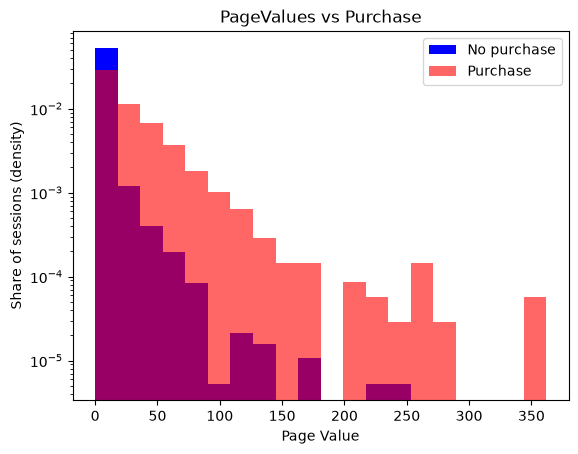

In [136]:
bins = np.linspace(0,df['PageValues'].max(),21)
plt.hist(pv_no, bins =bins, label = "No purchase",  color = 'b', density = True)
plt.hist(pv_buy, bins = bins, label = "Purchase", alpha = 0.6, color = 'r', density = True)

plt.yscale("log")

plt.xlabel("Page Value")
plt.ylabel("Share of sessions (density)")
plt.title("PageValues vs Purchase")

plt.legend()

plt.show()

## Hypothesis
- 89% of non-buyers have PageValues = 0, vs 19% of buyers, by definition, it's computed from pages visited before completing a purchase, so it may encode the outcome itself. It should be kept in mind to test the training process with and without PageValues.
